W niniejszym ćwiczeniu zostanie użyty algorytm śledzenia z rodziny filtrów korelacyjnych. W algorytmach tych wykorzystywany jest pewien filtr za pomocą którego zamodelowany jest śledzony obiekt. W celu predykcji nowego położenia obiektu, dokonywana jest korelacja obszaru śledzenia z filtrem. Obliczenia wykonywane są w dziedzinie częstotliwości, ponieważ szybciej jest obliczyć transformatę Fouriera za pomocą algorytmu FFT (*Fast Fourier Transform*) i skorzystać z twierdzenia o konwolucji, niż obliczać korelację wprost. Algorytmy śledzenia z rodziny filtrów korelacyjnych cechuje niska złożoność obliczeniowa (czyli możliwe jest śledzenie w czasie rzeczywistym) przy zachowaniu konkurencyjnej jakości śledzenia.

W dzisiejszym ćwiczeniu wykorzystana zostanie najprostsza wersja algorytmu opisana w publikacji:
https://www.cs.colostate.edu/~draper/papers/bolme_cvpr10.pdf

W pierwszej klatce obrazu filtr jest inicjalizowany na podstawie fragmentu obrazu w skali szarości $f$, który zawiera obiekt do śledzenia.

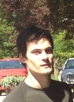

$H^*_t = \frac{A}{B}$

$A = \sum^N_i G_i \odot F^*_i$        (1a)

$B = \sum^N_i F_i \odot F^*_i$        (1b)

gdzie $F_i$ jest dyskretną transformatą Fouriera fragmentu obrazu $f_i$, natomiast $G$ jest transformatą Fouriera dwuwymiarowego rozkładu Gaussa $g$ o rozmiarze śledzonego obszaru: 

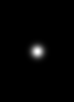

Działanie $\odot$ oznacza mnożenie typu element przez element, a $X^*$ oznacza sprzężenie zespolone (wynikiem transformacji Fouriera są liczby zespolone).

Suma po $i$ oznacza, że z jednej próbki obiektu w pierwszej klatce śledzenia należy utworzyć zbiór $N$ próbek uczących składających się z losowych rotacji próbki bazowej:

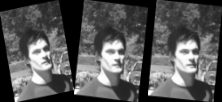

Następnie, w każdej klatce obrazu dokonywana jest predykcja położenia:

$\mathcal{F^{-1}}\{ F \odot H^* \}$      (2)

gdzie $\mathcal{F^{-1}}$ oznacza odwrotną, dyskretną transformację Fouriera, natomiast $F$ jest tutaj transformatą fragmentu obrazu scentrowanego na ostatnio znanej pozycji obiektu. Otrzymana w ten sposób mapa korelacji reprezentuje przewidziane prez filtr przesunięcie obiektu względem poprzedniej klatki obrazu:

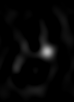

Po każdej predykcji, filtr jest aktualizowany fragmentem aktualnej klatki obrazu wyciętym na nowej pozycji obiektu:

$A_t = \eta G \odot F^*_t + (1-\eta) A_{t-1}$       (3a)

$B_t = \eta F_t \odot F^*_t + (1-\eta) B_{t-1}$     (3b)

Gdzie $\eta \in [0, 1]$ jest przyjętym współczynnikiem uczenia.

Na początek zaimportujmy potrzebne biblioteki i zadeklarujmy parametry algorytmu:

In [26]:
import os
from os.path import join
from pathlib import Path
from typing import cast

import cv2
import matplotlib.pyplot as plt
import numpy as np


NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "sequences").exists():
    EXERCISE_DIR = NOTEBOOK_DIR
elif (NOTEBOOK_DIR / "lab08" / "sequences").exists():
    EXERCISE_DIR = NOTEBOOK_DIR / "lab08"
else:
    raise FileNotFoundError("Cannot locate lab08/sequences directory from current working directory.")

DATASET_DIR = str(EXERCISE_DIR / "sequences")

SIGMA = 17
SEARCH_REGION_SCALE = 2
LR = 0.125
NUM_PRETRAIN = 128
VISUALIZE = False


def read_image_checked(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Unable to read image: {image_path}")
    return cast(np.ndarray, image)


def cv2_imshow(img):
    if img.ndim == 3:
        display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        display_img = img
    plt.figure(figsize=(6, 4))
    plt.imshow(display_img, cmap=None if img.ndim == 3 else "gray")
    plt.axis("off")
    plt.show()


Ćwiczenie przeprowadzone będzie z użyciem sekwencji ze zbioru VOT2013

Pomocnicze funkcje do czytania pliku zawierającego pozycje obiektu i wizualizacji zbioru:

In [27]:
def load_gt(gt_file):

    with open(gt_file, 'r') as file:
        lines = file.readlines()

    lines = [line.split(',') for line in lines]
    lines = [[int(float(coord)) for coord in line] for line in lines]
    # returns in x1y1wh format
    return lines


def show_sequence(sequence_dir):

    imgdir = join(sequence_dir, 'color')
    imgnames = os.listdir(imgdir)
    imgnames.sort()
    gt_boxes = load_gt(join(sequence_dir, 'groundtruth.txt'))

    for imgname, gt in zip(imgnames, gt_boxes):
        img = read_image_checked(image_path=join(imgdir, imgname))
        position = [int(x) for x in gt]
        cv2.rectangle(img, (position[0], position[1]), (position[0] + position[2], position[1] + position[3]), (255, 0, 0), 2)
        cv2_imshow(img)


In [28]:

# show_sequence(join(DATASET_DIR, 'jump'))

Na początek warto zaimplementować funkcję, która przyjmując klatkę obrazu oraz pozycję obiektu, zwróci fragment obrazu w skali szarości zawierający śledzony obiekt. Przyjmijmy, że położenie obiektu przekazywane jest w formacie $[x_1, y_1, w, h]$ ($x_1$, $y_1$) - lewy-górny punkt prostokąta otaczającego; $w$, $h$ - szerokość i wysokość).

Do śledzenia szybkich obiektów przydatnym jest uwzględniać nieco większy obszar scentrowany na pozycji obiektu, `SEARCH_REGION_SCALE` razy szerszy i wyższy niż sam obiekt.

🔔 **TODO (1)** zmodyfikować wartości `xmin, xmax, ymin, ymax` tak, aby obejmowały szerszy kontekst obrazu - wykorzystać zadeklarowany parametr `SEARCH_REGION_SCALE`.

🔔 **TODO (2)** Zabezpieczyć algorytm przed wykraczaniem obszaru poszukiwań poza kadr poprzez zastosowanie paddingu wejściowej klatki obrazu (przydatna funkcja: `frame = cv2.copyMakeBorder(frame, y_pad, y_pad, x_pad, x_pad, cv2.BORDER_REFLECT)` - padding przyjąć przynajmniej o rozmiarze obszaru poszukiwania). Należy pamiętać o tym, że współrzędne punktów na oryginalnym obrazie powinny zostać odpowiednio skorygowane o padding.

Warto przetestować zaimplementowaną funkcję poprzez wyświetlenie uzyskanego obszaru.

In [29]:
def crop_search_window(bbox, frame):
    xmin, ymin, width, height = bbox
    center_x = xmin + (width / 2.0)
    center_y = ymin + (height / 2.0)

    search_width = max(2, int(round(width * SEARCH_REGION_SCALE)))
    search_height = max(2, int(round(height * SEARCH_REGION_SCALE)))

    xmin = int(round(center_x - (search_width / 2.0)))
    ymin = int(round(center_y - (search_height / 2.0)))
    xmax = xmin + search_width
    ymax = ymin + search_height

    frame_height, frame_width = frame.shape[:2]
    pad_left = max(0, -xmin)
    pad_top = max(0, -ymin)
    pad_right = max(0, xmax - frame_width)
    pad_bottom = max(0, ymax - frame_height)

    if any(pad > 0 for pad in [pad_left, pad_top, pad_right, pad_bottom]):
        frame = cv2.copyMakeBorder(
            src=frame,
            top=pad_top,
            bottom=pad_bottom,
            left=pad_left,
            right=pad_right,
            borderType=cv2.BORDER_REFLECT,
        )
        xmin += pad_left
        xmax += pad_left
        ymin += pad_top
        ymax += pad_top

    window = frame[ymin:ymax, xmin:xmax, :]
    if window.shape[0] != search_height or window.shape[1] != search_width:
        window = cv2.resize(window, dsize=(search_width, search_height), interpolation=cv2.INTER_LINEAR)

    window = cv2.cvtColor(window, cv2.COLOR_BGR2GRAY)
    return window


Przydatna będzie funkcja generująca dwuwymiarowy rozkład Gaussa - kluczowe jest, aby ta funkcja oraz powyższa zwracały macierz o takich samych rozmiarach dla danego obiektu.

In [30]:
def get_gauss_response(gt_box):

    width = gt_box[2] * SEARCH_REGION_SCALE
    height = gt_box[3] * SEARCH_REGION_SCALE
    xx, yy = np.meshgrid(np.arange(width), np.arange(height))

    center_x = width // 2
    center_y = height // 2
    dist = (np.square(xx - center_x) + np.square(yy - center_y)) / (2 * SIGMA)
    response = np.exp(-dist)

    return response

Przed obliczeniem transformaty Fouriera, fragment obrazu należy odpowiednio przygotować.

🔔 **TODO (3)**
Proszę uzupełnić funkcję, która dokona preprocessingu wejściowego fragmentu obrazu w skali szarości:
- transformacja funkcją logarytm (warto dodać 1 do każdego piksela, aby uniknąć logarytmowania zera) - funkcja `np.log()`
- normalizacja (odjęcie wartości średniej i podzielenie przez odchylenie standardowe) - funkcje `np.mean()`, `np.std()`

Przemnożenie przez dwuwymiarowe okno Hanninga zostało zaimplementowane korzystając z funkcji `np.hanning()` generującą dyskretne, jednowymiarowe okno o zadanej szerokości. 

In [31]:
def pre_process(img):
    height, width = img.shape
    img = img.astype(np.float32)

    img = np.log(img + 1.0)
    img = (img - np.mean(img)) / (np.std(img) + 1e-5)

    #2d Hanning window
    win_col = np.hanning(width)
    win_row = np.hanning(height)
    mask_col, mask_row = np.meshgrid(win_col, win_row)
    window = mask_col * mask_row
    img = img * window

    return img


Do inicjalizacji należy wygenerować losowe próbki uczące. Do tego posłuży funkcja `random_warp`.

🔔 **TODO (4)** Proszę zaimplementować funkcję, która dokona losowej rotacji wejściowego fragmentu obrazu.
- wygenerować losowy kąt w zakrecie -+15 stopni (wykorzystać `np.random.uniform()` )
- obrócić obrazek o wylosowany kąt (funkcja `img_rot = imutils.rotate_bound(img, angle)` )
- przeskalować obrócony obrazek do oryginalnych rozmiarów wejściowego obrazka (funkcja `cv2.resize()` )

Funkcję również warto przetestować wizualnie przy użyciu funkcji `cv2.imshow()`. W przypadku problemów/wątpliwości zadanie można wykonać na koniec, algorytm powinien do pewnego stopnia zadziałać dla inicjalizacji tylko jedną próbką bazową.

In [32]:
def random_warp(img, max_rotation=10.0, scale_range=(0.9, 1.1), rng=None):
    if rng is None:
        rng = np.random.default_rng()

    height, width = img.shape
    center = (width / 2.0, height / 2.0)
    rotation = rng.uniform(low=-max_rotation, high=max_rotation)
    scale = rng.uniform(low=scale_range[0], high=scale_range[1])

    matrix = cv2.getRotationMatrix2D(center=center, angle=rotation, scale=scale)
    img_warped = cv2.warpAffine(
        src=img,
        M=matrix,
        dsize=(width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT,
    )
    img_resized = cv2.resize(img_warped, dsize=(width, height), interpolation=cv2.INTER_LINEAR)

    return img_resized


Poniżej przedstawiono implementację inicjalizacji na podstawie pierwszej klatki obrazu i pierwszej pozycji obiektu. Przed realizacją równań $(1a, 1b)$
, funkcja `pre_training()` wydobywa fragment obrazu, dokonuje preprocessingu i oblicza transformatę $F_i$ za pomocą zaimplementowanych wcześniej funkcji.
Wykorzystywana jest funkcja `np.fft.fft2()` realizująca algorytm FFT oraz `np.conjugate()` obliczająca sprzężenie zespolone.

Jeżeli funkcja `random_warp()` nie jest zaimplementowana, pierwsze eksperymenty należy przeprowadzić dla `NUM_PRETRAIN = 0`.


In [33]:
def initialize(init_frame, init_gt):

    g = get_gauss_response(gt_box=init_gt)
    G = np.fft.fft2(g)
    Ai, Bi = pre_training(init_gt=init_gt, init_frame=init_frame, G=G)

    return Ai, Bi, G


def pre_training(init_gt, init_frame, G):

    template = crop_search_window(bbox=init_gt, frame=init_frame)
    fi = pre_process(img=template)

    Ai = G * np.conjugate(np.fft.fft2(fi))                # (1a)
    Bi = np.fft.fft2(fi) * np.conjugate(np.fft.fft2(fi))  # (1b)

    for _ in range(NUM_PRETRAIN):
        fi = pre_process(img=random_warp(img=template))

        Ai = Ai + G * np.conjugate(np.fft.fft2(fi))               # (1a)
        Bi = Bi + np.fft.fft2(fi) * np.conjugate(np.fft.fft2(fi)) # (1b)

    return Ai, Bi


Niżej zaimplementowana funkcja `track()` przedstawia wysokopoziomowo jedną iterację działania algorytmu śledzenia. Przyjmuje ona aktualne parametry filtru oraz aktualną pozycję obiektu (w drugiej klatce śledzenia będą to parametry uzyskanie z inicjalizacji oraz pozycja startowa obiektu) i zwraca obliczoną pozycję oraz zaktualizowany filtr.

In [34]:
def track(image, position, Ai, Bi, G, return_response=False):

    response = predict(frame=image, position=position, H=Ai / Bi)
    new_position = update_position(spatial_response=response, position=position)
    newAi, newBi = update(frame=image, position=new_position, Ai=Ai, Bi=Bi, G=G)

    if return_response:
        return new_position, newAi, newBi, response

    return new_position, newAi, newBi, None


🔔 **TODO (5)** W oparciu o schemat działania funkcji `track()`, proszę zaimplementować brakujące funkcje:
- `predict()` realizującą równanie $(2)$, czyli odpowiedź filtru,
- `update()` realizującą równania $(3a, 3b)$,

Analogicznie do funkcji `pre_training()`, należy na sam początek wykorzystać funkcję `crop_search_window()` do wycięcia odpowiedniego fragmentu obrazu oraz funkcję `pre_process()` do wstępnej obróbki tego fragmentu.

Do wyznaczenia odwrotnej transformaty Fouriera w funkcji `predict()` proszę wykorzystać funkcję `np.fft.ifft2()`. Funkcja `predict()` powinna zwracać macierz rzeczywistą, dlatego proszę użyć funkcji `np.real()` przed zwróceniem ostatecznej wartości.

W funkcji `update()` proszę wykorzystać parametr `LR` będący współczynnikiem uczenia przy aktualizacji filtru.

🔔 **TODO (6)** Pozostało jeszcze zaimplementować funkcję `update_position()`, która przyjmując odpowiedź filtru, zwróci nową pozycję obiektu.

- należy wyznaczyć współrzędne elementu o największej wartości (podpowiedź: funkcja `np.max(response)` zwraca maksymalną wartość macierzy `response`, a funkcja `np.where(response == max_val)` zwraca indeks macierzy `response`, który ma wartość `max_val`)
- może się zdarzyć, że więcej niż jeden indeks będzie miał wartość maksymalną - aby się przed tym zabezpieczyć można uwzględniać tylko pierwszy indeks zwrócony przez `np.where()` lub jeszcze lepiej - obliczyć średni indeks (`np.mean()`),
- przesunięcie maksymalnej wartości od środka odpowiedzi filtru jest przewidzianym przesunięciem położenia obiektu - należy zmodyfikować pierwszą i drugą współrzędną położenia (zmiany w szerokości i wysokości obiektu ignorujemy w tym ćwiczeniu).

In [35]:
def predict(frame, position, H):

    search_window = crop_search_window(bbox=position, frame=frame)
    fi = pre_process(img=search_window)
    Fi = np.fft.fft2(fi)

    Gi = H * Fi
    gi = np.real(np.fft.ifft2(Gi))

    return gi


def update(frame, position, Ai, Bi, G):

    search_window = crop_search_window(bbox=position, frame=frame)
    fi = pre_process(img=search_window)
    Fi = np.fft.fft2(fi)

    new_Ai = (1 - LR) * Ai + LR * (G * np.conjugate(Fi))
    new_Bi = (1 - LR) * Bi + LR * (Fi * np.conjugate(Fi))

    return new_Ai, new_Bi


def update_position(spatial_response, position):

    peak_y, peak_x = np.unravel_index(np.argmax(spatial_response), spatial_response.shape)
    response_height, response_width = spatial_response.shape

    delta_x = peak_x - (response_width // 2)
    delta_y = peak_y - (response_height // 2)

    if delta_x > response_width / 2:
        delta_x -= response_width
    if delta_y > response_height / 2:
        delta_y -= response_height

    new_position = position.copy()
    new_position[0] = float(new_position[0] + delta_x)
    new_position[1] = float(new_position[1] + delta_y)

    return new_position


Zaimplementowany system proszę przetestować poprzez prostą metrykę będącą średnim IoU w każdej klatce śledzenia

(dać te gotowe funkcje lub kazać samemu to zrobić)
(w folderze są sekwencje jump - prostsza, sunshade - trudniejsza)

In [36]:
def bbox_iou(box1, box2):

    b1_x1, b1_x2 = box1[0], box1[0] + box1[2]
    b1_y1, b1_y2 = box1[1], box1[1] + box1[3]
    b2_x1, b2_x2 = box2[0], box2[0] + box2[2]
    b2_y1, b2_y2 = box2[1], box2[1] + box2[3]

    inter_rect_x1 = max(b1_x1, b2_x1)
    inter_rect_y1 = max(b1_y1, b2_y1)
    inter_rect_x2 = min(b1_x2, b2_x2)
    inter_rect_y2 = min(b1_y2, b2_y2)

    inter_area = np.clip(inter_rect_x2 - inter_rect_x1, a_min=0, a_max=None) * np.clip(inter_rect_y2 - inter_rect_y1, a_min=0, a_max=None)
    b1_area = (b1_x2 - b1_x1) * (b1_y2 - b1_y1)
    b2_area = (b2_x2 - b2_x1) * (b2_y2 - b2_y1)

    iou = inter_area / (b1_area + b2_area - inter_area + 1e-16)

    return iou


def _draw_bbox(image, bbox, color=(255, 0, 0), thickness=2):
    boxed = image.copy()
    x, y, w, h = [int(round(value)) for value in bbox]
    cv2.rectangle(boxed, (x, y), (x + w, y + h), color, thickness)
    return boxed


def _plot_tracking_diagnostic(frame, previous_position, predicted_position, response, frame_id):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

    axes[0].imshow(cv2.cvtColor(_draw_bbox(image=frame, bbox=previous_position, color=(0, 255, 255)), cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Frame {frame_id}: previous bbox")
    axes[0].axis("off")

    axes[1].imshow(response, cmap="viridis")
    peak_y, peak_x = np.unravel_index(np.argmax(response), response.shape)
    axes[1].scatter(peak_x, peak_y, c="red", s=40, label="peak")
    axes[1].legend(loc="upper right")
    axes[1].set_title("DCF response map")

    axes[2].imshow(cv2.cvtColor(_draw_bbox(image=frame, bbox=predicted_position, color=(255, 0, 0)), cv2.COLOR_BGR2RGB))
    axes[2].set_title("Updated bbox")
    axes[2].axis("off")

    fig.tight_layout()


def test_sequence(DATASET_DIR, sequence, visualize_steps=False, diagnostic_every=15):

    seqdir = join(DATASET_DIR, sequence)
    imgdir = join(seqdir, 'color')
    imgnames = os.listdir(imgdir)
    imgnames.sort()

    print('init frame:', join(imgdir, imgnames[0]))
    init_img = read_image_checked(image_path=join(imgdir, imgnames[0]))
    gt_boxes = load_gt(gt_file=join(seqdir, 'groundtruth.txt'))
    position = gt_boxes[0]
    Ai, Bi, G = initialize(init_frame=init_img, init_gt=position)

    if VISUALIZE or visualize_steps:
        cv2_imshow(_draw_bbox(image=init_img, bbox=position))

    results = []
    for frame_id, imgname in enumerate(imgnames[1:], start=1):
        img = read_image_checked(image_path=join(imgdir, imgname))

        if visualize_steps:
            previous_position = position.copy()
            position, Ai, Bi, response = track(
                image=img,
                position=position,
                Ai=Ai,
                Bi=Bi,
                G=G,
                return_response=True,
            )
            if frame_id % diagnostic_every == 0:
                _plot_tracking_diagnostic(
                    frame=img,
                    previous_position=previous_position,
                    predicted_position=position,
                    response=response,
                    frame_id=frame_id,
                )
        else:
            position, Ai, Bi, _ = track(image=img, position=position, Ai=Ai, Bi=Bi, G=G)

        results.append(position.copy())

        if VISUALIZE:
            cv2_imshow(_draw_bbox(image=img, bbox=position))

    return results, gt_boxes


def plot_iou_curve(sequence, results, gt_boxes):
    ious = [bbox_iou(box1=res_box, box2=gt_box) for res_box, gt_box in zip(results, gt_boxes[1:])]
    mean_iou = float(np.mean(ious))

    plt.figure(figsize=(10, 4))
    plt.plot(ious, label="IoU per frame", linewidth=1.7)
    plt.axhline(mean_iou, color="red", linestyle="--", label=f"Mean IoU = {mean_iou:.3f}")
    plt.title(f"{sequence}: IoU during tracking")
    plt.xlabel("Frame index")
    plt.ylabel("IoU")
    plt.ylim(0.0, 1.0)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

    return ious, mean_iou


### Wizualizacje działania DCF

Poniżej dodano trzy typy wizualizacji:
- podgląd losowych deformacji `random_warp` (żeby sprawdzić jakość próbek uczących),
- diagnostykę krokową śledzenia (poprzedni bbox, mapa odpowiedzi filtra, nowy bbox),
- wykres IoU w funkcji numeru klatki oraz średnie IoU.


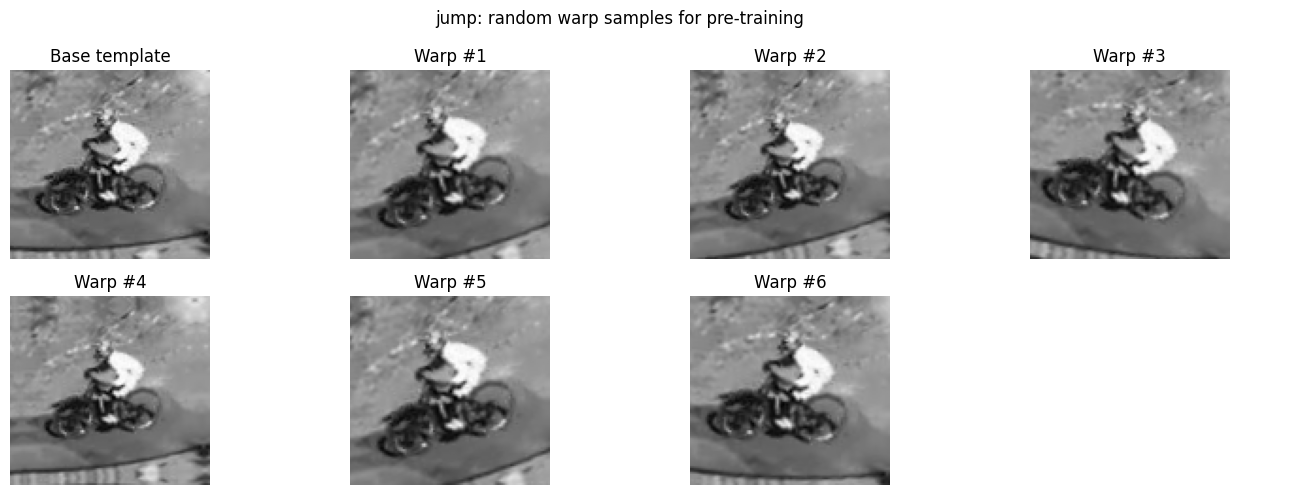


=== Sequence: jump ===
init frame: /Users/marcinwolder/Desktop/repo/zaw/lab08/sequences/jump/color/00000001.jpg


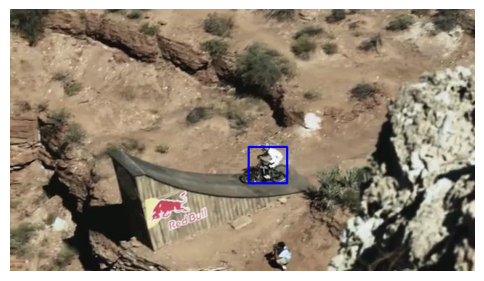

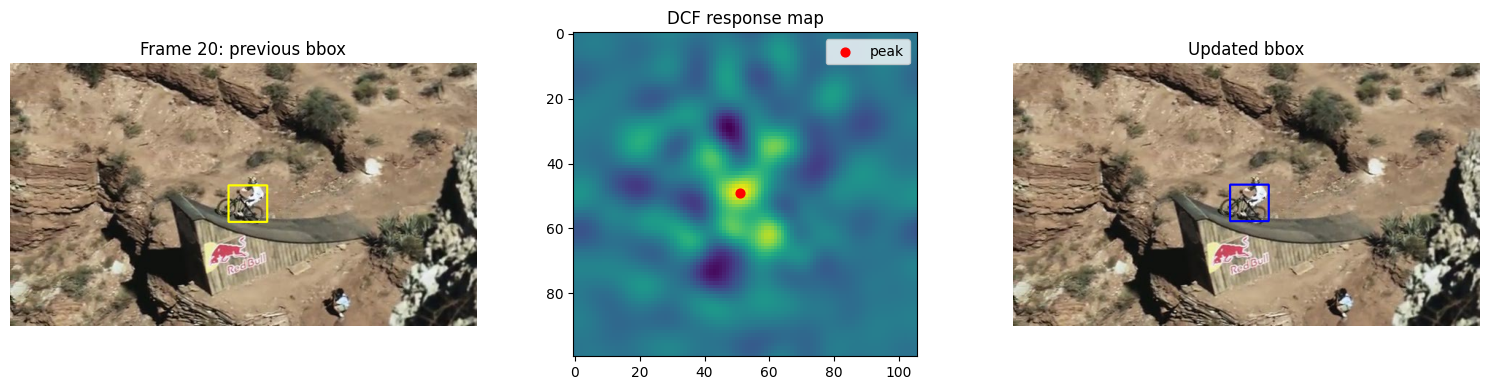

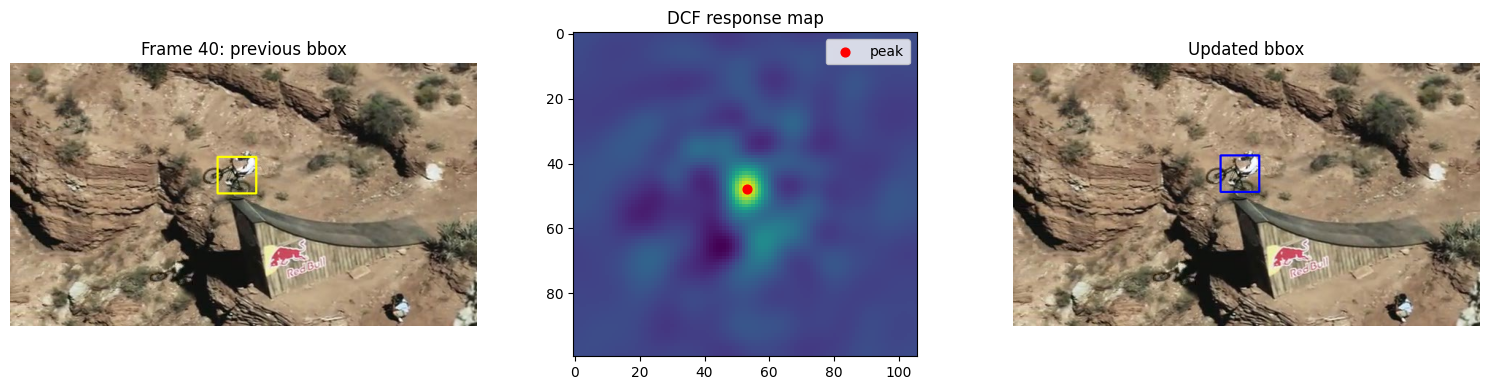

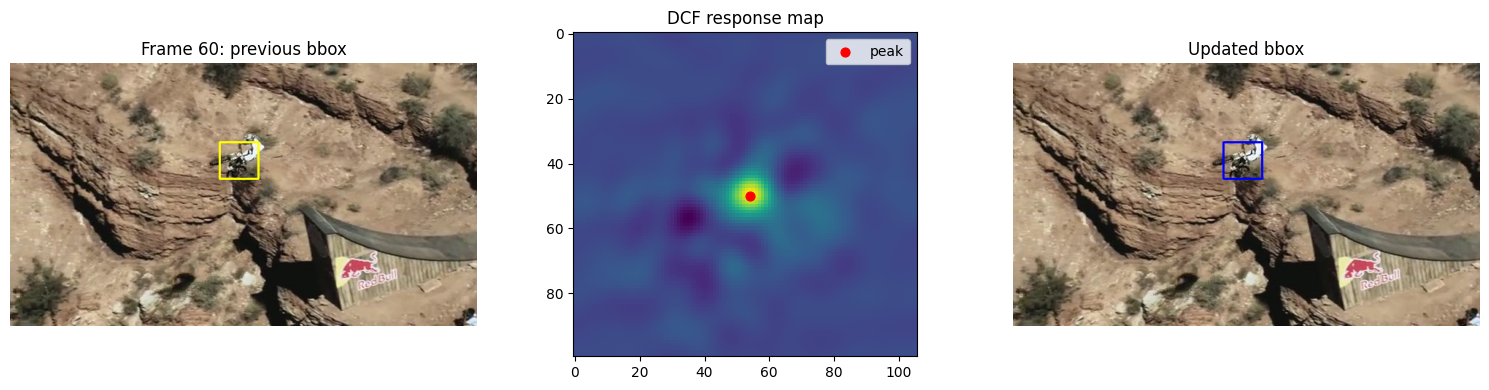

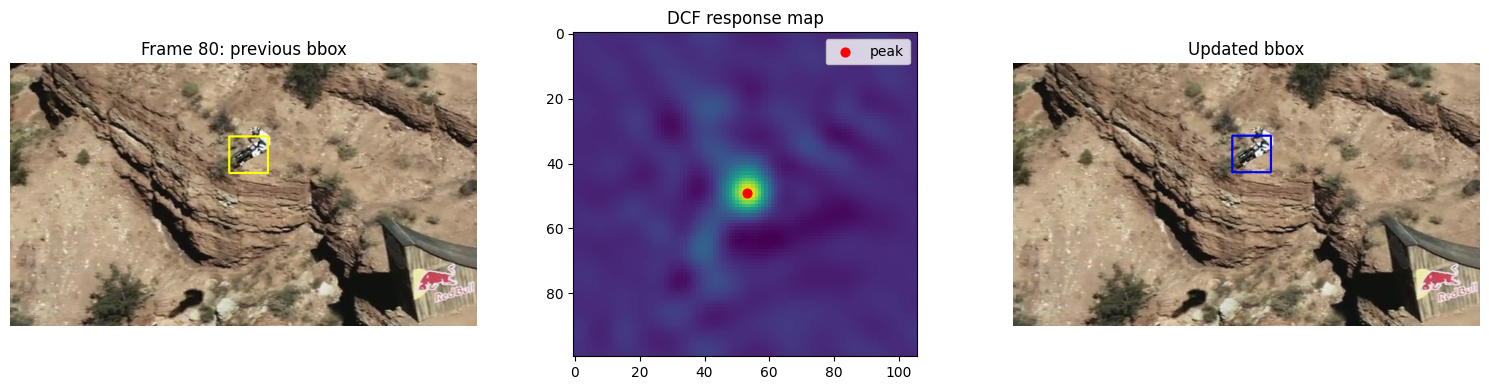

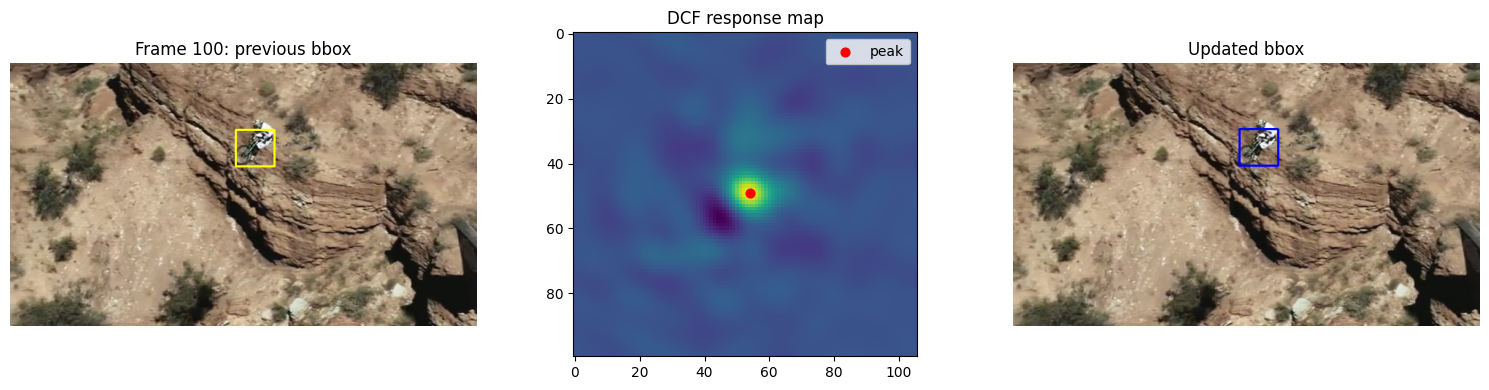

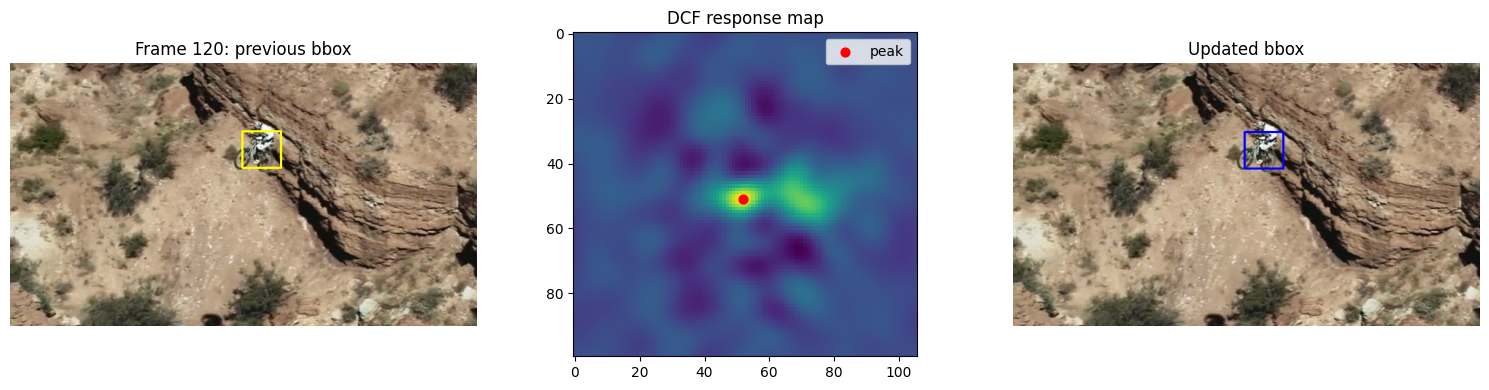

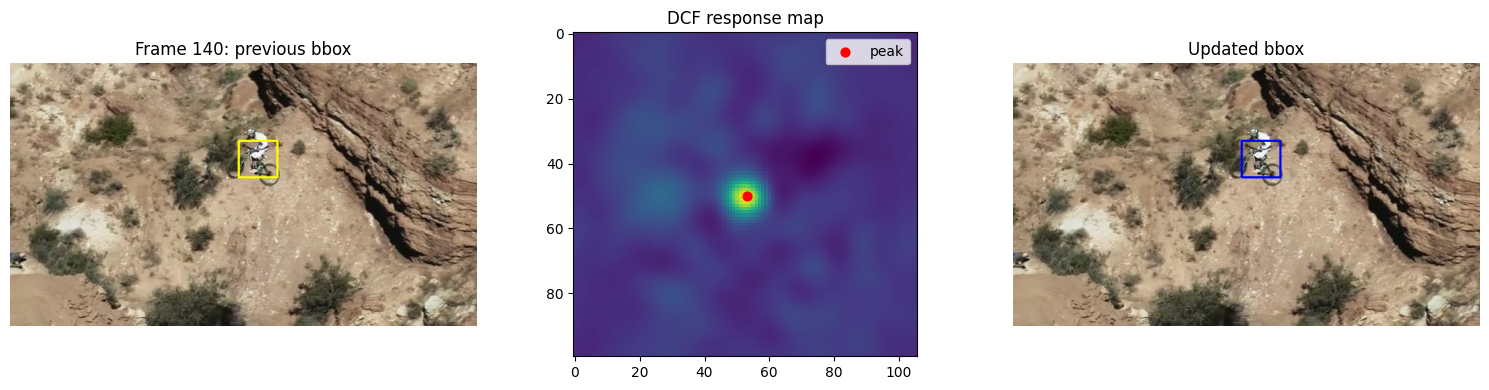

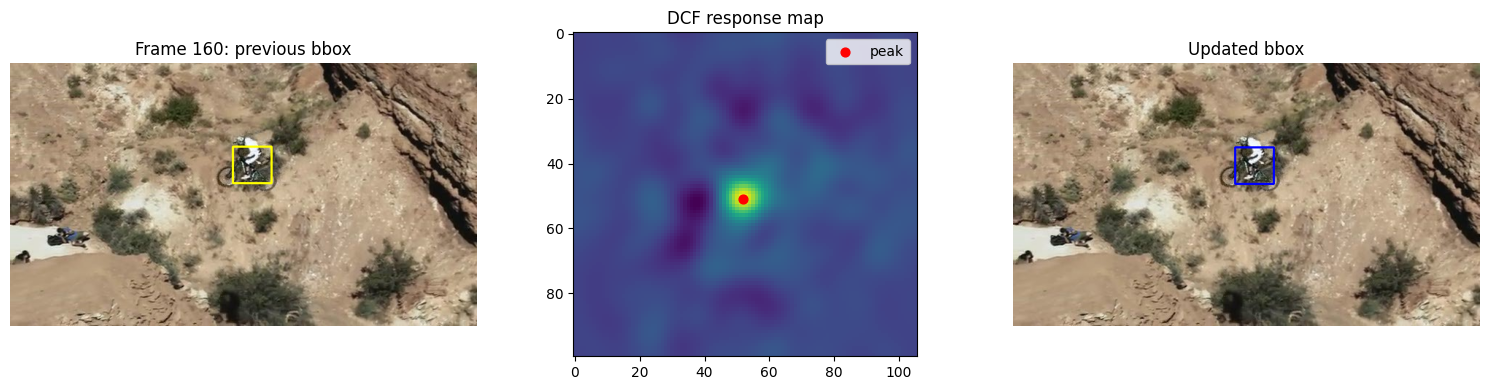

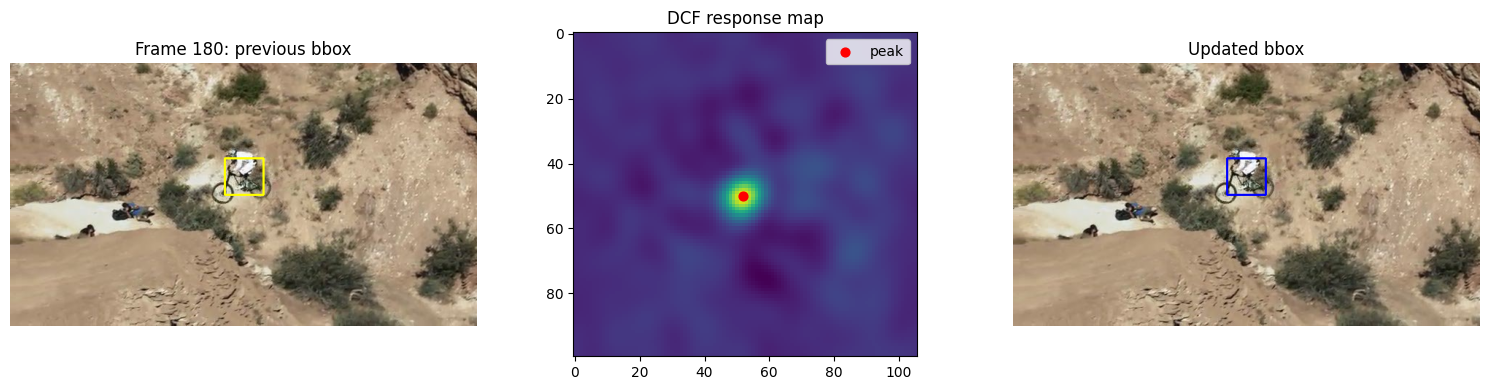

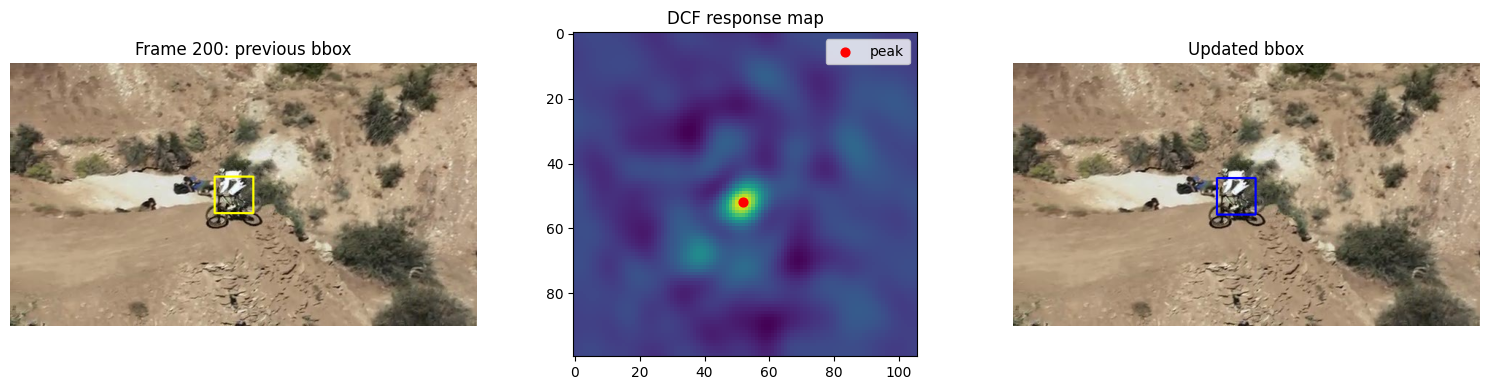

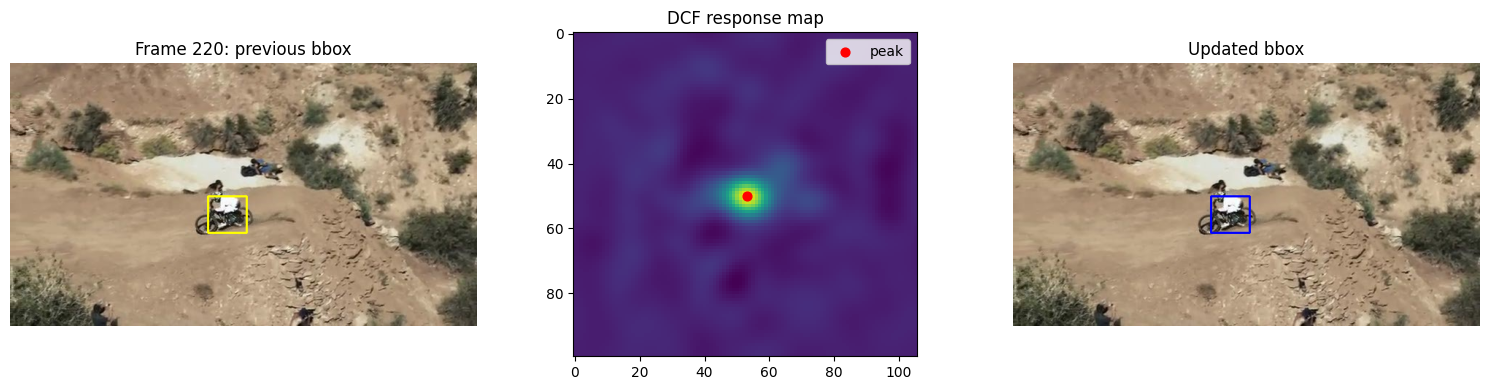

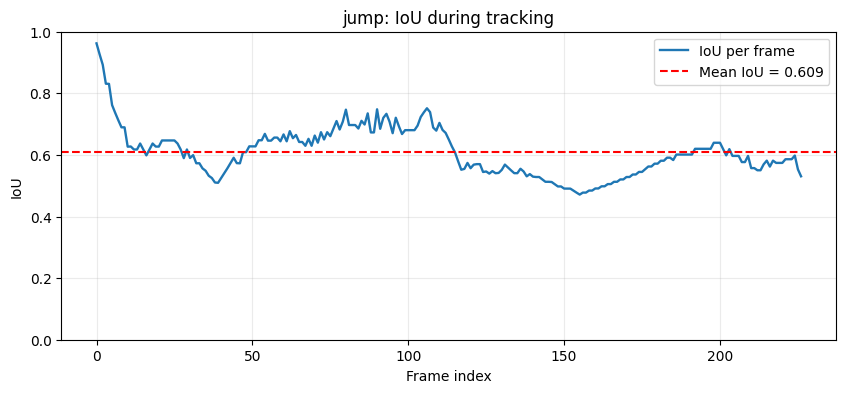

jump: mean IoU = 0.6088

=== Sequence: sunshade ===
init frame: /Users/marcinwolder/Desktop/repo/zaw/lab08/sequences/sunshade/color/00000001.jpg


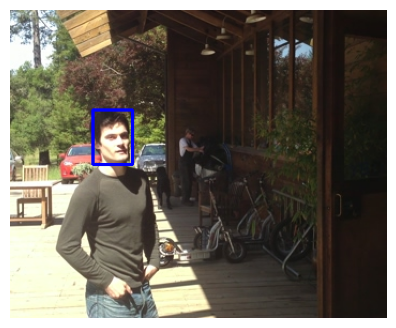

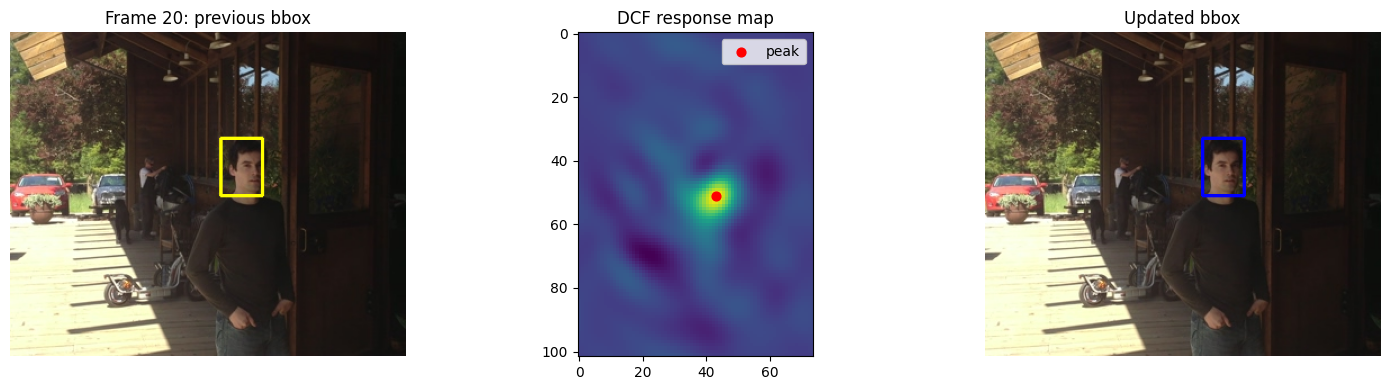

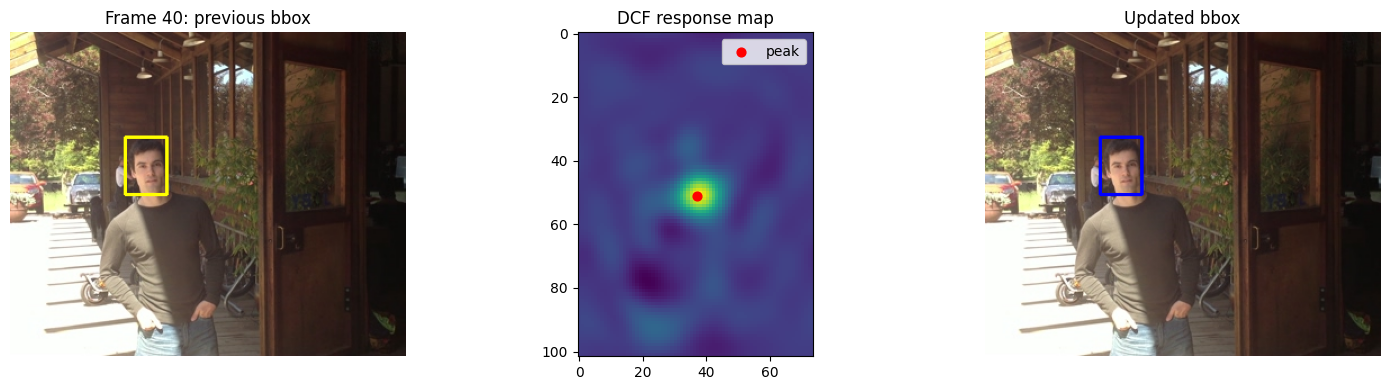

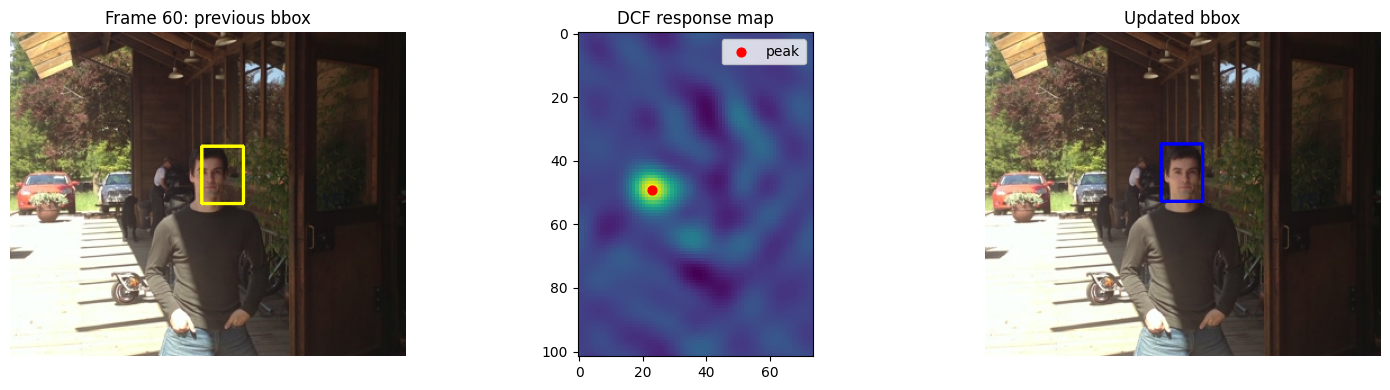

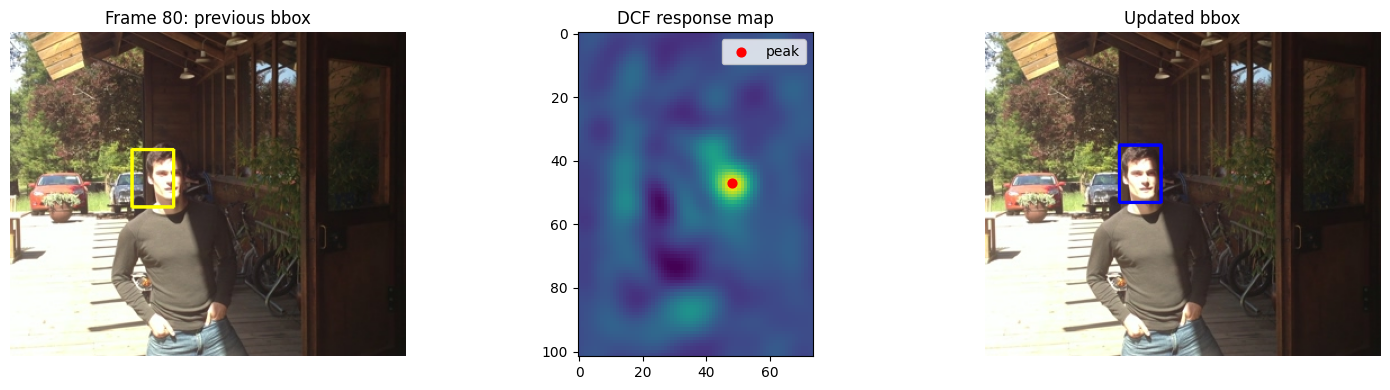

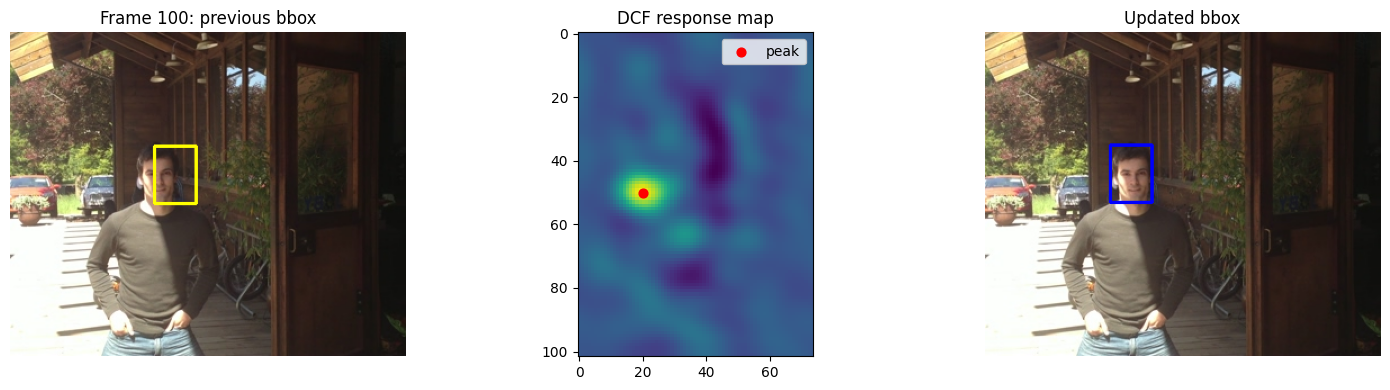

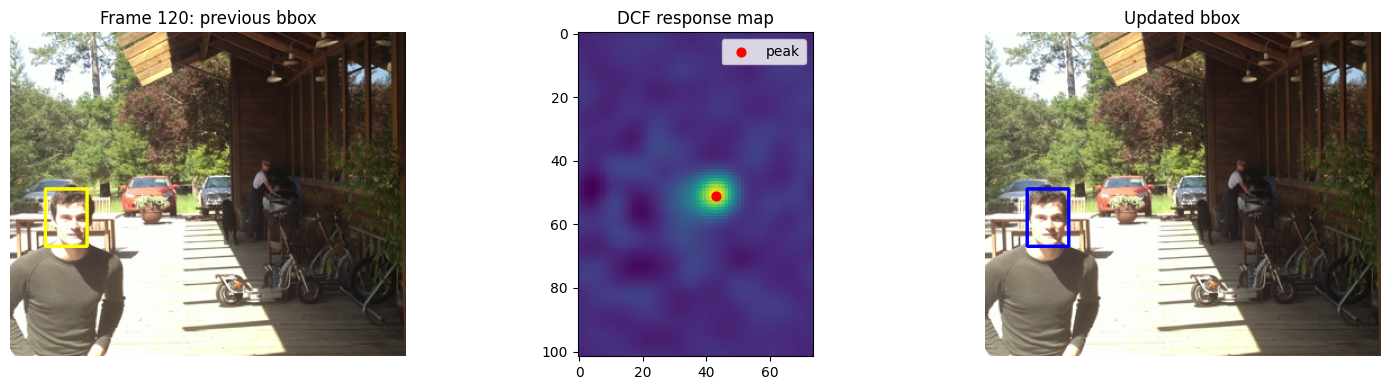

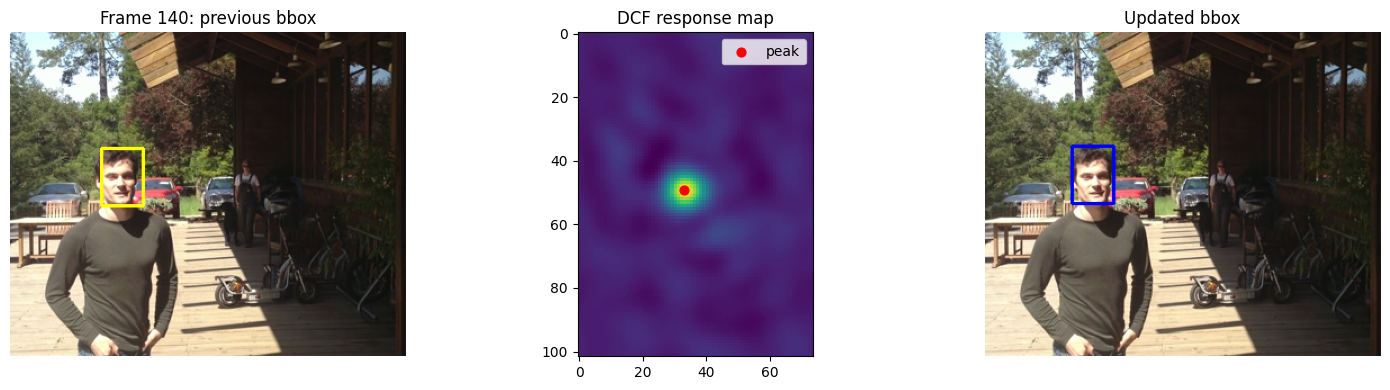

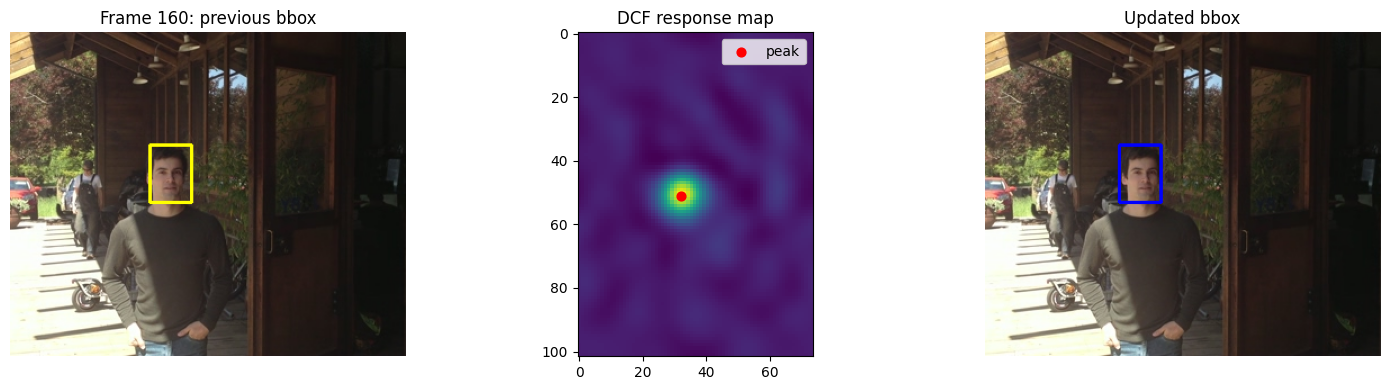

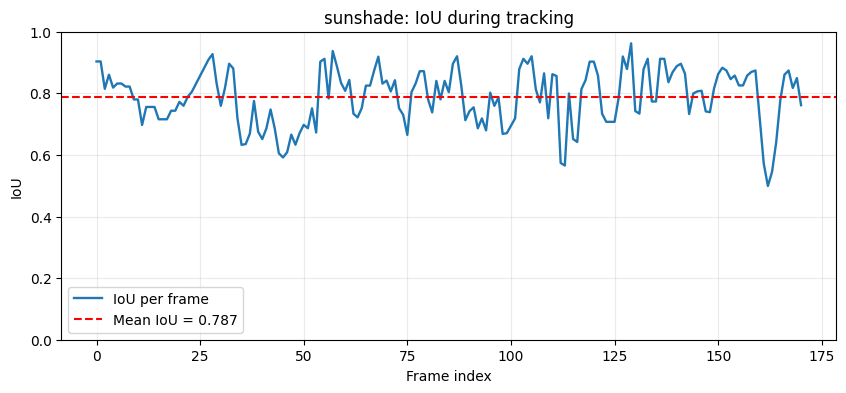

sunshade: mean IoU = 0.7869

Global mean IoU: 0.6978107407383527


In [37]:
def visualize_random_warp_samples(sequence, sample_count=6, random_seed=7):
    rng = np.random.default_rng(seed=random_seed)

    seqdir = join(DATASET_DIR, sequence)
    imgdir = join(seqdir, 'color')
    first_img_name = sorted(os.listdir(imgdir))[0]
    frame = read_image_checked(image_path=join(imgdir, first_img_name))
    gt_box = load_gt(gt_file=join(seqdir, 'groundtruth.txt'))[0]

    template = crop_search_window(bbox=gt_box, frame=frame)

    figure, axes = plt.subplots(nrows=2, ncols=sample_count // 2 + 1, figsize=(14, 5))
    flat_axes = axes.ravel()

    flat_axes[0].imshow(template, cmap="gray")
    flat_axes[0].set_title("Base template")
    flat_axes[0].axis("off")

    for idx in range(sample_count):
        warped = random_warp(img=template, max_rotation=15.0, rng=rng)
        flat_axes[idx + 1].imshow(warped, cmap="gray")
        flat_axes[idx + 1].set_title(f"Warp #{idx + 1}")
        flat_axes[idx + 1].axis("off")

    for idx in range(sample_count + 1, len(flat_axes)):
        flat_axes[idx].axis("off")

    figure.suptitle(f"{sequence}: random warp samples for pre-training")
    figure.tight_layout()
    plt.show()


SEQUENCES = ['jump', 'sunshade']
VISUALIZE_DIAGNOSTICS = True
DIAGNOSTIC_EVERY = 20

visualize_random_warp_samples(sequence='jump', sample_count=6, random_seed=13)

ious_per_sequence = {}
for sequence in SEQUENCES:
    print(f"\n=== Sequence: {sequence} ===")
    results, gt_boxes = test_sequence(
        DATASET_DIR=DATASET_DIR,
        sequence=sequence,
        visualize_steps=VISUALIZE_DIAGNOSTICS,
        diagnostic_every=DIAGNOSTIC_EVERY,
    )
    _, mean_iou = plot_iou_curve(sequence=sequence, results=results, gt_boxes=gt_boxes)
    ious_per_sequence[sequence] = mean_iou
    print(f"{sequence}: mean IoU = {mean_iou:.4f}")

print('\nGlobal mean IoU:', float(np.mean(list(ious_per_sequence.values()))))
